In [269]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [270]:
def calcular_deltaX(L1,L2,N):
    return (L2 - L1)/(N-1)

In [271]:
def cond_dirichlet(posicion,N,T): 
    """
    0: izquierda 
    otra cosa es: derecha

    """
    row = np.zeros(N)

    if posicion == 0:

        row[0] = 1
        f = T


        return row,f


    row[N-1] = 1
    f= T

    return row,f         


def cond_neumann(posicion, N, dx, k, c, G, q):
    row = np.zeros(N)

    if posicion == 0:
        row[0] = 2 + (dx**2 * c) / k
        row[1] = -2
        f = (dx**2 * G[0] - 2 * dx * q) / k
        return row, f

    row[N - 2] = -2
    row[N - 1] = 2 + (dx**2 * c) / k
    f = (dx**2 * G[N - 1] - 2 * dx * q) / k

    return row, f

def cond_robin(posicion,N,dx,k,c,G,h,phi_inf): 
    """
    0: izquierda 
    otra cosa es: derecha
    """
    
    row = np.zeros(N)

    if posicion == 0:


        row[0]= 2 + (dx**2 * c) / k + (2 * dx * h) / k
        row[1] = -2

        f = (dx**2 * G[0]) / k + (2 * dx * h * phi_inf) / k


        return row,f

    row[N - 1] = 2 + (dx**2 * c) / k + (2 * dx * h) / k
    row[N - 2] = -2

    f = (dx**2 * G[N-1]) / k + (2 * dx * h * phi_inf) / k


    return row,f

In [ ]:
def calcularMatriz(xnode,model,cb):

    dx = np.diff(xnode)[0]


    N = len(xnode)
    matriz = np.zeros((N,N))


    k = model["k"]
    c = model["c"]
    G = model["G"]
    

    condicion_izq = {
        1: cond_dirichlet(posicion=0,N=N,T=cb[0][1]),
        2: cond_neumann(
            posicion=0,N=N,dx=dx,k=k,c=c,G=G,q=cb[0][1]
        ),
        3: cond_robin(
            posicion=0,N=N,dx=dx,k=k,c=c,G=G,h=cb[0][1],phi_inf=cb[0][2]
        )
    }


    condicion_der = {
        1: cond_dirichlet(posicion=1,N=N,T=cb[1][1]),
        2: cond_neumann(posicion=1,N=N,dx=dx,k=k,c=c,G=G,q=cb[1][1]),
        3: cond_robin(
            posicion=1,N=N,dx=dx,k=k,c=c,G=G,h=cb[1][1],phi_inf=cb[1][2]
        )
    }

    row_izq,f_izq = condicion_izq[cb[0][0]]

    matriz[0] = row_izq

    for i in range(1,N-1):
        matriz[i][i - 1] = 1.0
        matriz[i][i] = -(2.0 + (dx**2 * c) / k)
        matriz[i][i + 1] = 1.0

    matriz[N-1],f_der = condicion_der[cb[1][0]] 


    F = -(dx**2 * G) / k

    F[0] = f_izq
    F[N-1] = f_der


    return matriz,F

In [273]:
def resolverMatrix(k,f):

    kinv = np.linalg.inv(k)

    return np.dot(kinv,f)

In [274]:
def graficar(L1,L2,N,solucion,solucionNumerica):

    x = np.linspace(L1,L2,100)
    ysol = solucion(x)
    plt.figure(figsize=(10, 6))

    plt.plot(x,ysol,label='Solución Analítica', color='blue', linewidth=2)

    plt.scatter(np.linspace(L1,L2,N),solucionNumerica.flatten(),label='Solución Numérica', color='red', s=50)

    plt.show()


In [ ]:
def resolver_ejercicio(xnode,model,cb,solucion_analitica=None):


    K,F = calcularMatriz(
        xnode = xnode,
        model = model,
        cb = cb
    )

    solucionNumerica = resolverMatrix(K,F)


    if solucion_analitica is not None:
        graficar(xnode[0],xnode[-1],len(xnode),solucion_analitica,solucionNumerica)


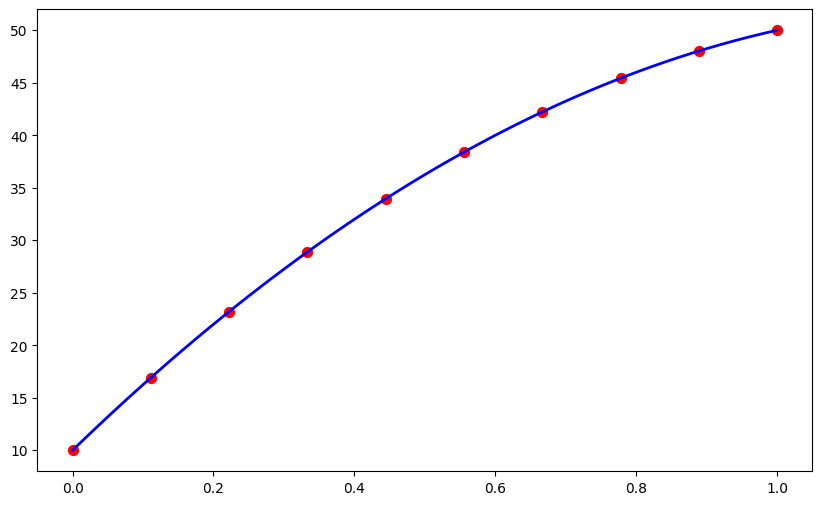

In [276]:
# ejercicio a

def a_solucion_analitica(x):
    return (-25 * (x**2) + 65 * x + 10)

L1 = 0
L2 = 1
N = 10
k = 2
c = 0
G = np.full(N, 100)

xnode = np.linspace(L1,L2,N)

model = {
    "k": k,
    "c": c,
    "G": G
}



cb = [
    [1, 10,-1],  # condición de borde izquierda: dirichlet, T=10
    [1, 50,-1]   # condición de borde derecha: dirichlet, T=50
]


resolver_ejercicio(
    model = model,
    xnode = xnode,
    cb = cb,
    solucion_analitica = a_solucion_analitica
)



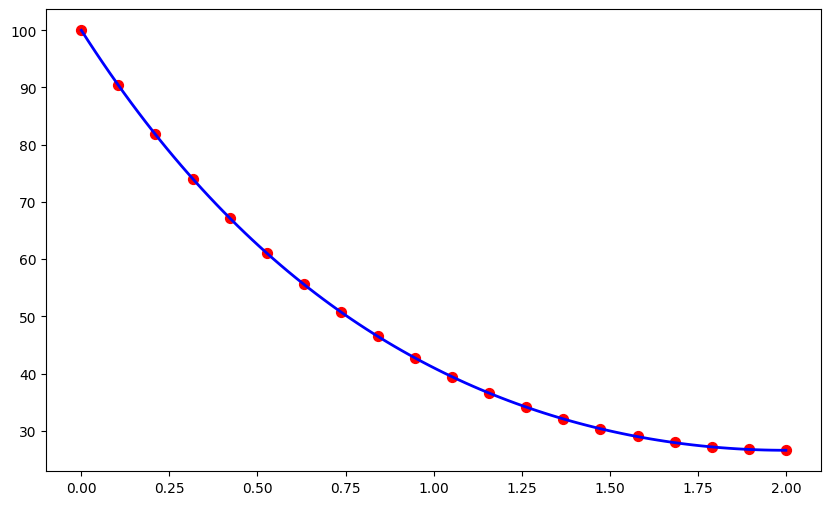

In [277]:

# ejercicio b
def b_solucion_analitica(x):
    return (100*np.exp(-x)*(np.exp(2*x)+np.exp(4)))/(1+np.exp(4))

L1 = 0
L2 = 2
N = 20

k = 1
c = 1
G = np.full(N, 0)
T1=100
q=0


xnode = np.linspace(L1,L2,N)

model = {
    "k": k,
    "c": c,
    "G": G
}

cb = [
    [1, T1,-1],  # condición de borde izquierda: dirichlet, T=100
    [2, q,-1]   # condición de borde derecha: neumann, q=0
]

resolver_ejercicio(
    model = model,
    xnode = xnode,
    cb = cb,
    solucion_analitica = b_solucion_analitica
)



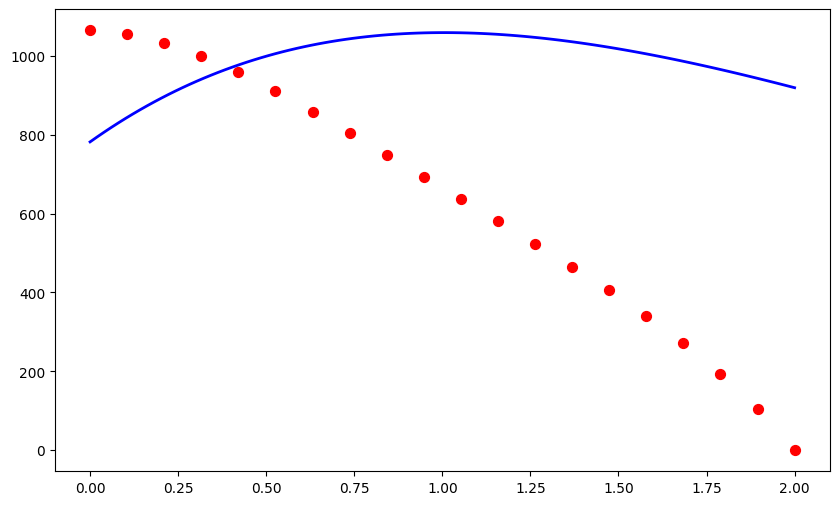

In [278]:
import numpy as np

# ==========================================
# ÍTEM C
# ==========================================
# Extremos: L1 = 1, L2 = 5
# Bordes: L1 -> q = 2 (Neumann), L2 -> T = 0 (Dirichlet)
# Constantes: k = 1, c = 0, G(x) = 100*(x - 3)**2


def c_solucion_analitica(x):
    a = -1350
    b = 1906
    c_const = 2345
    return (-25 * (x**4) + 300 * (x**3) + a * (x**2) + b * x + c_const) / 3.0


L1_c, L2_c, N_c = 1, 5, 20
x_c = np.linspace(L1_c, L2_c, N_c)
G_c = 100.0 * (x_c - 3.0) ** 2


model_c = {
    "k": 1.0,
    "c": 0.0,
    "G": G_c
}

cb = [
    [2, 2.0, -1],  # condición de borde izquierda: neumann, q=2
    [1, 0.0, -1]   # condición de borde derecha: dirichlet, T=0
]


xnode_c = np.linspace(L1_c, L2_c, N_c)

resolver_ejercicio(
    model=model_c,
    xnode=xnode_c,
    cb=cb,
    solucion_analitica=c_solucion_analitica,
)


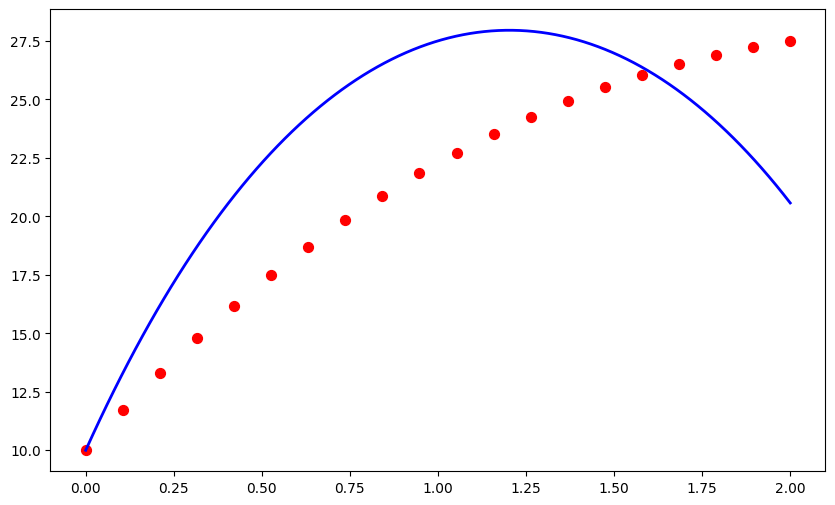

In [279]:

# ==========================================
# ÍTEM D
# ==========================================
# Extremos: L1 = 0, L2 = 1
# Bordes: L1 -> T = 10 (Dirichlet), L2 -> h = 0.2, phi_inf = 50 (Robin)
# Constantes: k = 1, c = 1, G = 50


def d_solucion_analitica(x):
    return -36.6897 * np.exp(-x) - 3.3103 * np.exp(x) + 50.0


L1_d, L2_d, N_d = 0, 1, 20
G_d = np.full(N_d, 50.0)


model = {
    "k": 1.0,
    "c": 1.0,
    "G": G_d
}

xnode_d = np.linspace(L1_d, L2_d, N_d)

cb = [
    [1, 10.0, -1],  # condición de borde izquierda: dirichlet, T=10
    [3, 0.2, 50.0]  # condición de borde derecha: robin, h=0.2, phi_inf=50
]

resolver_ejercicio(
    model=model,
    xnode=xnode_d,
    cb=cb,
    solucion_analitica=d_solucion_analitica,
)


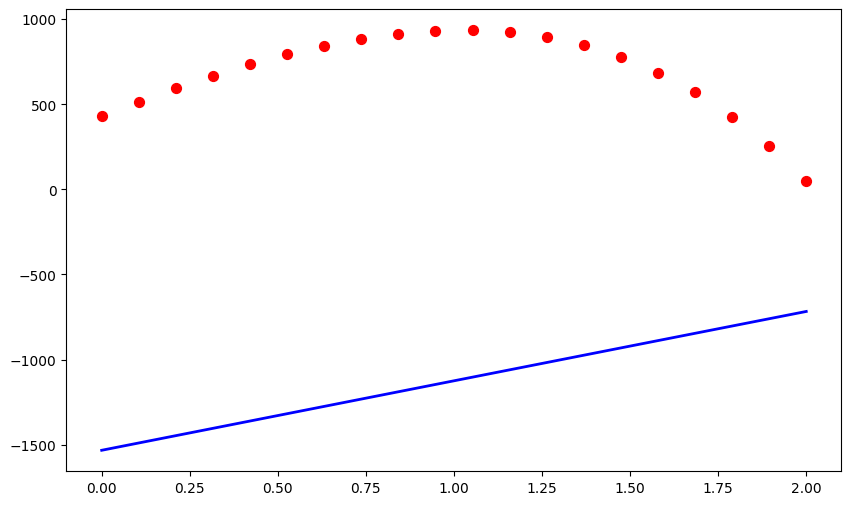

In [280]:

# ==========================================
# ÍTEM E
# ==========================================
# Extremos: L1 = 5, L2 = 10
# Bordes: L1 -> h = 2, phi_inf = 100 (Robin), L2 -> T = 50 (Dirichlet)
# Constantes: k = 2, c = 0, G(x) = x**3


def e_solucion_analitica(x):
    return (-(x**5) / 40.0) + (1225.0 * x / 3.0) - (4600.0 / 3.0)


L1_e, L2_e, N_e = 5, 10, 20
x_e = np.linspace(L1_e, L2_e, N_e)
G_e = x_e**3


xnode_e = np.linspace(L1_e, L2_e, N_e)

model = {

    "k": 2.0,
    "c": 0.0,
    "G": G_e
}

resolver_ejercicio(
    model=model,
    xnode=xnode_e,
    cb=[
        [3, 2.0, 100.0],  # condición de borde izquierda: robin, h=2, phi_inf=100
        [1, 50.0, -1]     # condición de borde derecha: dirichlet, T=50
    ],
    solucion_analitica=e_solucion_analitica,
)



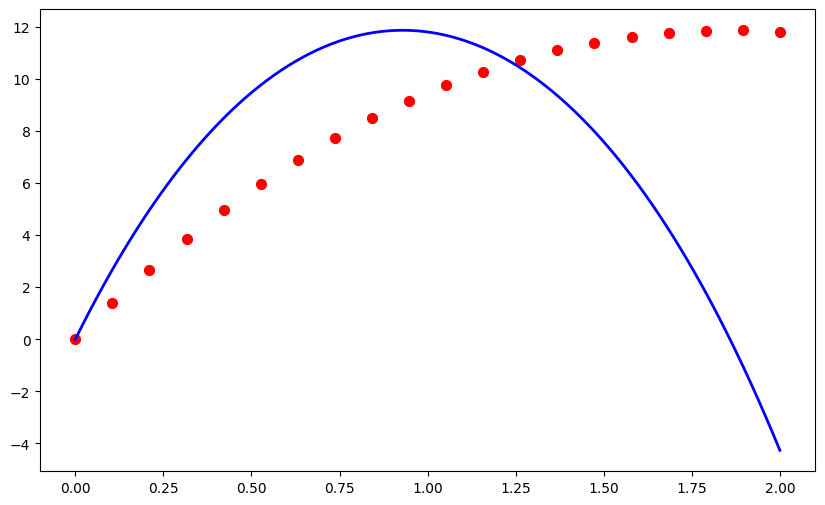

In [281]:

# ==========================================
# ÍTEM F
# ==========================================
# Extremos: L1 = 0, L2 = 1
# Bordes: L1 -> T = 0 (Dirichlet), L2 -> h = 2, phi_inf = 10 (Robin)
# Constantes: k = 2, c = 2, G = 75


def f_solucion_analitica(x):
    a = 11.0 - 30.0 * np.exp(1.0)
    return (-5.0 / 4.0) * np.exp(-(x + 1.0)) * (np.exp(x) - 1.0) * (11.0 * np.exp(x) + a)


L1_f, L2_f, N_f = 0, 1, 20
G_f = np.full(N_f, 75.0)
xnode_f = np.linspace(L1_f, L2_f, N_f)

model = {
    "k": 2.0,
    "c": 2.0,
    "G": G_f
}

resolver_ejercicio(
    model=model,
    xnode=xnode_f,
    cb=[
        [1, 0.0, -1],  # condición de borde izquierda: dirichlet, T=0
        [3, 2.0, 10.0] # condición de borde derecha: robin, h=2, phi_inf=10
    ],
    solucion_analitica=f_solucion_analitica,
)


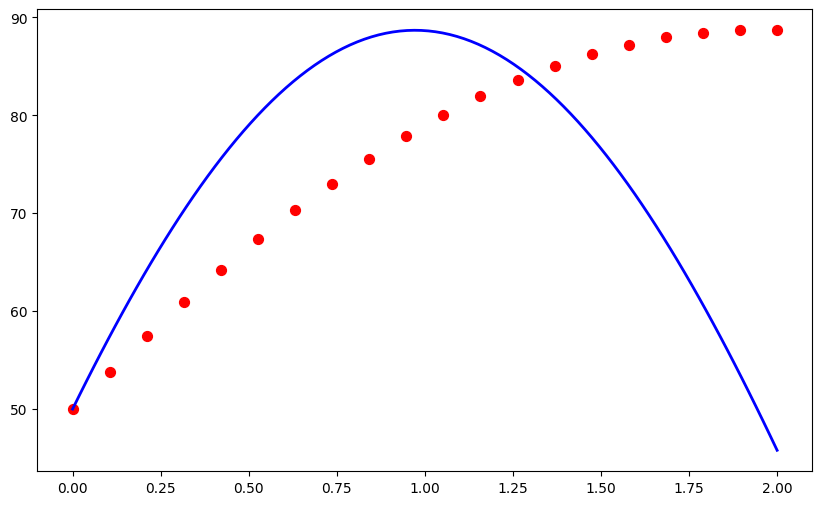

In [282]:

# ==========================================
# ÍTEM G
# ==========================================
# Extremos: L1 = 0, L2 = 1
# Bordes: L1 -> T = 50 (Dirichlet), L2 -> q = 5 (Neumann)
# Constantes: k = 2, c = -2, G = 0


def g_solucion_analitica(x):
    return 73.2433 * np.sin(x) + 50.0 * np.cos(x)


L1_g, L2_g, N_g = 0, 1, 20
G_g = np.full(N_g, 0.0)

model = {
    "k": 2.0,
    "c": -2.0,
    "G": G_g
}

xnode_g = np.linspace(L1_g, L2_g, N_g)

cb_g = [
    [1, 50.0, -1],  # condición de borde izquierda:
    # dirichlet, T=50
    [2, 5.0, -1]    # condición de borde derecha: neumann, q=5
        
]

resolver_ejercicio(
    model=model,
    xnode=xnode_g,
    cb=cb_g,
    solucion_analitica=g_solucion_analitica,
)